# Credit Card Fraud Detection using Gaussian Anomaly Detection and XGBoost

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PowerTransformer

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score

In [2]:
# Load dataset
df = pd.read_csv("creditcard.csv")

print(df.shape)
print(df["Class"].value_counts())
df.head()


(284807, 31)
Class
0    284315
1       492
Name: count, dtype: int64


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

<Axes: >

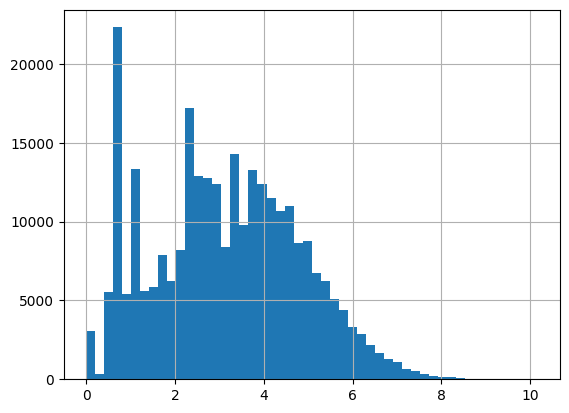

In [4]:
df = df.drop('Time', axis=1)

df["Amount_log"] = np.log1p(df["Amount"])
df = df.drop(columns='Amount')
df["Amount_log"].hist(bins=50)

Class
0    284315
1       492
Name: count, dtype: int64


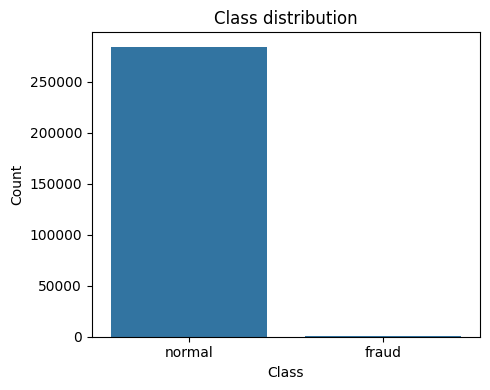

In [5]:
# Separate normal and fraud
normal_df = df[df["Class"] == 0]
fraud_df = df[df["Class"] == 1]


# Class distribution
counts = df['Class'].value_counts()
print(counts)


plt.figure(figsize=(5, 4))
sns.countplot(x='Class', data=df)
plt.xticks([0, 1], ['normal', 'fraud'])
plt.title('Class distribution')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [6]:
normal_df.columns

Index(['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11',
       'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21',
       'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Class', 'Amount_log'],
      dtype='str')

In [7]:
# X_normal = normal_df.drop(columns='Class')
# X_fraud = fraud_df.drop(columns='Class')

In [8]:
X_train_normal, X_temp_normal = train_test_split(normal_df, test_size=0.4, random_state=42)

X_cv_normal, X_test_normal = train_test_split(X_temp_normal, test_size=0.5, random_state=42)

X_cv_fraud, X_test_fraud = train_test_split(fraud_df, test_size=0.5, random_state=42)

In [9]:
X_train_normal.shape, X_cv_normal.shape, X_test_normal.shape, X_cv_fraud.shape, X_test_fraud.shape

((170589, 30), (56863, 30), (56863, 30), (246, 30), (246, 30))

In [10]:
X_train = X_train_normal.drop(columns='Class').values

#cross validation df
df_cv  = pd.concat([X_cv_normal, X_cv_fraud]).sample(frac=1, random_state=42)
X_cv   = df_cv.drop(columns='Class').values
y_cv   = df_cv['Class'].values

# test df
df_test = pd.concat([X_test_normal, X_test_fraud]).sample(frac=1, random_state=42)
X_test  = df_test.drop(columns='Class').values
y_test  = df_test['Class'].values

print(f'\nX_train: {X_train.shape} — all normal, no labels')
print(f'X_cv:   {X_cv.shape}  — fraud count: {y_cv.sum()}')
print(f'X_test:  {X_test.shape} — fraud count: {y_test.sum()}')


X_train: (170589, 29) — all normal, no labels
X_cv:   (57109, 29)  — fraud count: 246
X_test:  (57109, 29) — fraud count: 246


In [11]:
from sklearn.preprocessing import PowerTransformer

feature_names = X_train_normal.drop(columns="Class").columns

#rebuild from the original split data
X_train_df = X_train_normal.drop(columns="Class").copy()
X_cv_df = df_cv.drop(columns="Class").copy()
X_test_df = df_test.drop(columns="Class").copy()

train_skewness = X_train_df.skew().abs().sort_values(ascending=False)
heavy_skewed = train_skewness[train_skewness > 1]

print(train_skewness.head(15).round(3))
print(f"\nHeavy skewed > 1: {heavy_skewed.index.tolist()}")
print(f"Count: {len(heavy_skewed)}")



V28    14.927
V8      7.568
V23     6.587
V2      5.148
V21     3.548
V27     3.476
V1      3.211
V10     2.467
V3      1.411
V7      1.374
V12     1.302
V6      1.263
V14     0.781
V20     0.753
V9      0.690
dtype: float64

Heavy skewed > 1: ['V28', 'V8', 'V23', 'V2', 'V21', 'V27', 'V1', 'V10', 'V3', 'V7', 'V12', 'V6']
Count: 12


In [12]:
if not heavy_skewed.empty:
    transformer = PowerTransformer(method="yeo-johnson", standardize=False)

    # remove V6, it gets worse after transformation
    skewed_cols = [col for col in heavy_skewed.index.tolist() if col != "V6"]

    print(f"Transforming: {skewed_cols}")

    if skewed_cols:
        X_train_df[skewed_cols] = transformer.fit_transform(X_train_df[skewed_cols])
        X_cv_df[skewed_cols] = transformer.transform(X_cv_df[skewed_cols])
        X_test_df[skewed_cols] = transformer.transform(X_test_df[skewed_cols])

        transform_skewness = X_train_df[skewed_cols].skew().abs().sort_values(ascending=False)

        print("\nSkewness after Yeo-Johnson:")
        print(transform_skewness.round(3))

X_train = X_train_df.to_numpy()
X_cv = X_cv_df.to_numpy()
X_test = X_test_df.to_numpy()

Transforming: ['V28', 'V8', 'V23', 'V2', 'V21', 'V27', 'V1', 'V10', 'V3', 'V7', 'V12']

Skewness after Yeo-Johnson:
V8     1.869
V21    1.617
V27    1.212
V28    1.016
V10    0.655
V7     0.430
V2     0.247
V1     0.219
V23    0.180
V12    0.130
V3     0.057
dtype: float64


# Scale data for anomaly 


In [13]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_cv_scaled = scaler.transform(X_cv)
X_test_scaled = scaler.transform(X_test)


In [14]:
feature_names = X_train_normal.drop(columns='Class').columns
# pd.DataFrame(X_train_scaled, columns=feature_names).skew().abs() > 1
train_skew1 = pd.DataFrame(X_train, columns=feature_names).skew().abs().sort_values(ascending=False)

train_skew = pd.DataFrame(X_train, columns=feature_names)
train_skew1

V8            1.868928
V21           1.616945
V6            1.263402
V27           1.212112
V28           1.015641
V14           0.780697
V20           0.753385
V9            0.690285
V10           0.655029
V4            0.571616
V26           0.568563
V24           0.562865
V16           0.492013
V25           0.431259
V7            0.429858
V5            0.342950
V15           0.309917
V2            0.246611
V1            0.219179
V22           0.216056
V23           0.179887
Amount_log    0.166084
V11           0.157551
V12           0.130390
V17           0.094184
V19           0.091105
V13           0.063281
V3            0.057367
V18           0.043686
dtype: float64

array([[<Axes: title={'center': 'V1'}>, <Axes: title={'center': 'V2'}>,
        <Axes: title={'center': 'V3'}>, <Axes: title={'center': 'V4'}>,
        <Axes: title={'center': 'V5'}>],
       [<Axes: title={'center': 'V6'}>, <Axes: title={'center': 'V7'}>,
        <Axes: title={'center': 'V8'}>, <Axes: title={'center': 'V9'}>,
        <Axes: title={'center': 'V10'}>],
       [<Axes: title={'center': 'V11'}>, <Axes: title={'center': 'V12'}>,
        <Axes: title={'center': 'V13'}>, <Axes: title={'center': 'V14'}>,
        <Axes: title={'center': 'V15'}>],
       [<Axes: title={'center': 'V16'}>, <Axes: title={'center': 'V17'}>,
        <Axes: title={'center': 'V18'}>, <Axes: title={'center': 'V19'}>,
        <Axes: title={'center': 'V20'}>],
       [<Axes: title={'center': 'V21'}>, <Axes: title={'center': 'V22'}>,
        <Axes: title={'center': 'V23'}>, <Axes: title={'center': 'V24'}>,
        <Axes: title={'center': 'V25'}>],
       [<Axes: title={'center': 'V26'}>, <Axes: title={'cen

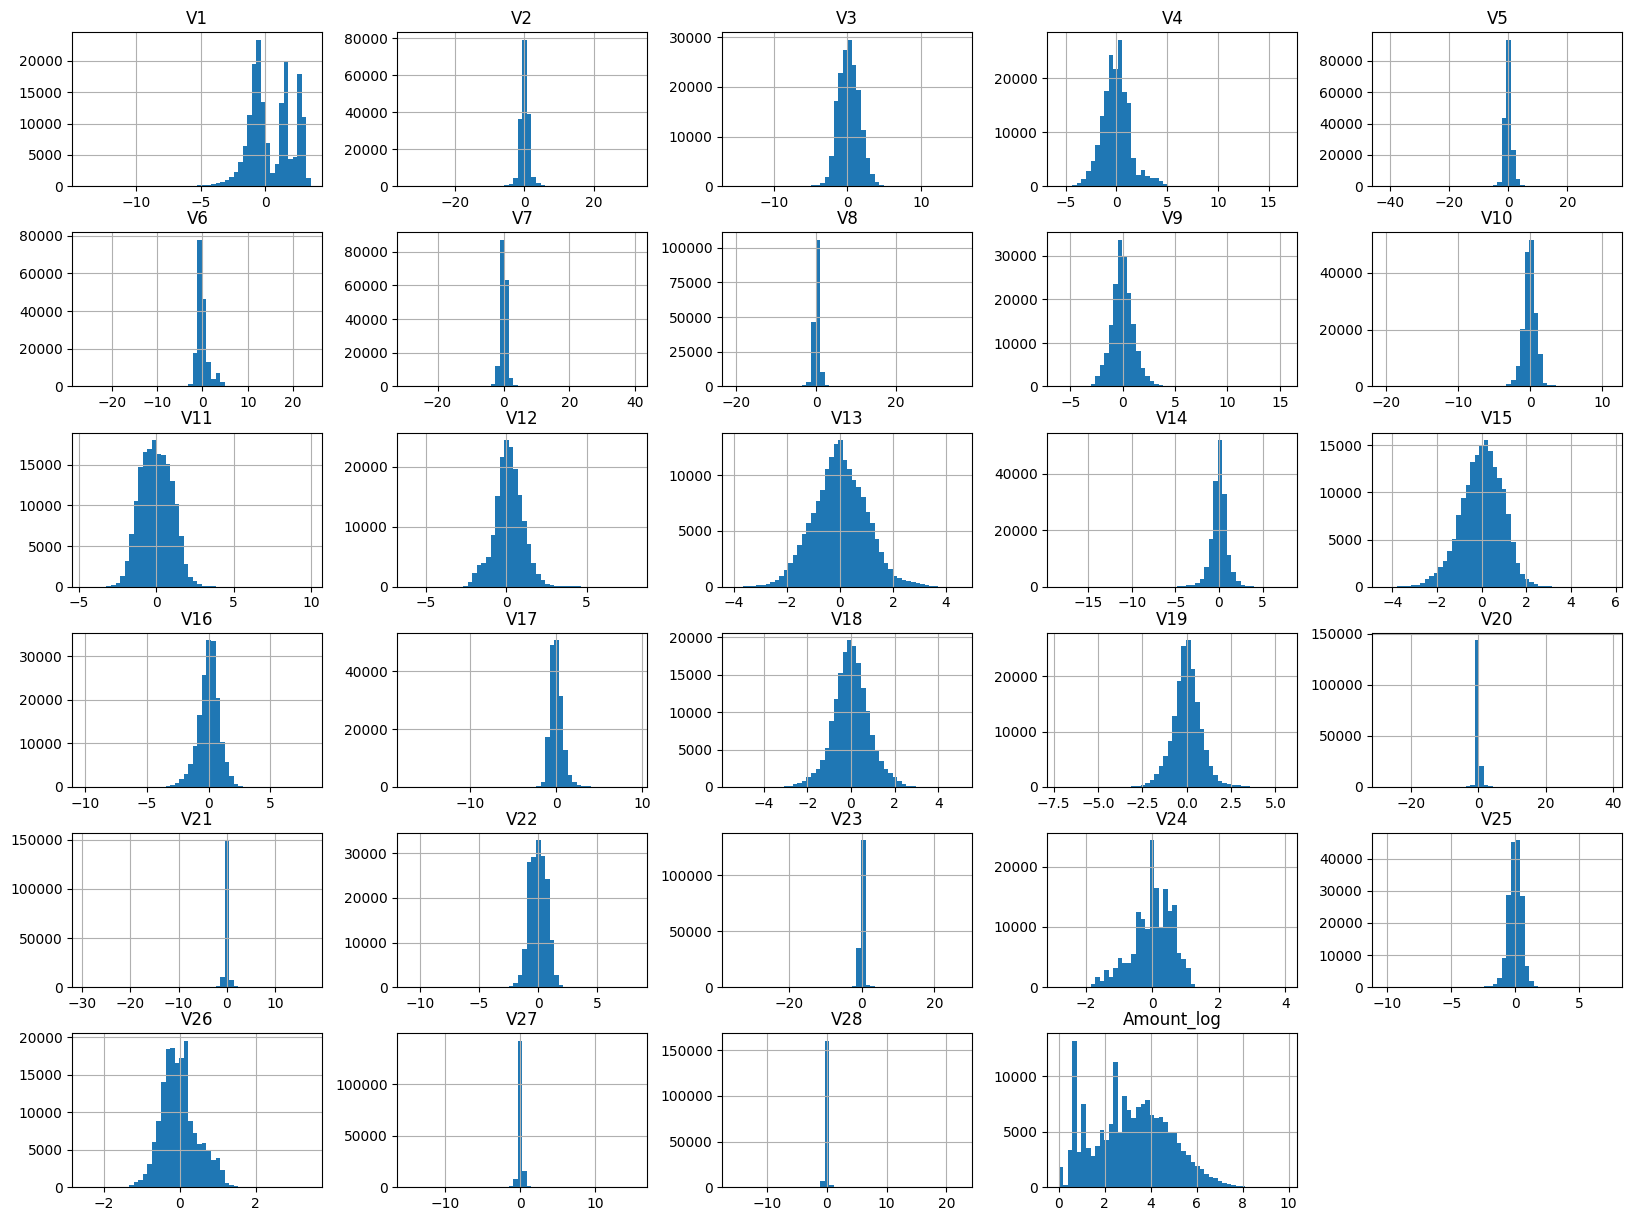

In [15]:
train_skew.hist(bins=50, figsize=(20, 15))

In [16]:
#estimate gaussian parameters
def estimate_gaussian(X):
    mu = np.mean(X, axis=0)
    var = np.var(X, axis=0)
    return mu, var


def multivariate_gaussian_log(X, mu, var):
    """
    to avoid multiplying many small probabilities.
    """    
    log_coefficient = -0.5 * np.sum(np.log(2 * np.pi * var))
    
    log_exponent = -0.5 * np.sum(((X - mu) ** 2) / var, axis=1)
    
    log_p = log_coefficient + log_exponent
    
    return log_p

# def multivariate_gaussian(X, mu, var):
#     k = len(mu)
    
#     coefficient = 1 / np.sqrt((2 * np.pi) ** k * np.prod(var))
#     exponent = -0.5 * np.sum(((X - mu) ** 2) / var, axis=1)
    
#     p = coefficient * np.exp(exponent)
    
#     return p

# select best epsilon
def select_threshold(y_cv, p_cv):
    best_epsilon = None
    best_f1 = 0
    
    epsilons = np.linspace(p_cv.min(), p_cv.max(), 5000)
    
    for epsilon in epsilons:
        predictions = (p_cv < epsilon).astype(int)
        f1 = f1_score(y_cv, predictions)
        
        if f1 > best_f1:
            best_f1 = f1
            best_epsilon = epsilon
            
    return best_epsilon, best_f1

# # Train Gaussian model & Compute probabilities

In [17]:
mu, var = estimate_gaussian(X_train_scaled)

p_train = multivariate_gaussian_log(X_train_scaled, mu, var)
p_cv = multivariate_gaussian_log(X_cv_scaled, mu, var)
p_test = multivariate_gaussian_log(X_test_scaled, mu, var)

# Choose epsilon
epsilon, best_f1 = select_threshold(y_cv, p_cv)

print('best epsilon:', epsilon)
print('best validation F1-score:', best_f1)

best epsilon: -228.620002958246
best validation F1-score: 0.4038095238095238


Confusion Matrix:
[[56691   172]
 [  142   104]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56863
           1       0.38      0.42      0.40       246

    accuracy                           0.99     57109
   macro avg       0.69      0.71      0.70     57109
weighted avg       0.99      0.99      0.99     57109



Text(0.5, 1.0, 'Gaussian Anomaly detection cm')

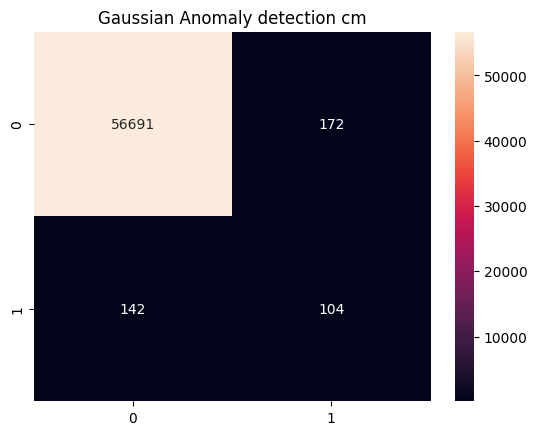

In [18]:
# Test evaluation
y_pred_test = (p_test < epsilon).astype(int)


gaussian_precision = precision_score(y_test, y_pred_test, zero_division=0)
gaussian_recall = recall_score(y_test, y_pred_test, zero_division=0)
gaussian_f1 = f1_score(y_test, y_pred_test, zero_division=0)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_test))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_test))


sns.heatmap(confusion_matrix(y_test, y_pred_test), annot=True, fmt='d')
plt.title('Gaussian Anomaly detection cm')

## Error Analysis

In [19]:
error_df = X_test_df.copy()

error_df['actual'] = y_test
error_df['predicted'] = y_pred_test
error_df['log_probability'] = p_test
error_df['correct'] = error_df['actual'] == error_df['predicted']

error_df["error_type"] = "Correct"

error_df.loc[
    (error_df["actual"] == 0) & (error_df['predicted'] == 1),
    'error_type'
] = 'False Positive'

error_df.loc[
    (error_df['actual'] == 1) & (error_df['predicted'] == 0),
    "error_type"
] = 'False Negative'

error_df["error_type"].value_counts()

error_type
Correct           56795
False Positive      172
False Negative      142
Name: count, dtype: int64

In [20]:
false_positives = error_df[error_df['error_type'] == "False Positive"]
false_positives.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V25,V26,V27,V28,Amount_log,actual,predicted,log_probability,correct,error_type
22466,-5.661351,10.987298,-7.604966,2.113988,-7.702480,-2.522812,-5.664097,14.091741,0.117159,0.032100,...,0.737160,-0.323541,-0.189024,-0.331731,4.510750,0,1,-269.673693,False,False Positive
30551,-6.967981,-8.143036,-4.141154,6.026010,-1.350931,-2.113742,0.077876,1.504504,-0.056984,-0.763594,...,1.146854,0.210469,5.177167,-10.816521,0.693147,0,1,-780.054092,False,False Positive
56144,-5.100659,-6.944386,-1.405342,2.192816,4.911351,-4.091028,-6.799854,-3.526018,0.453540,-0.948291,...,-1.571334,0.885521,3.790305,-4.240466,5.571051,0,1,-275.723412,False,False Positive
45967,-4.468888,-6.048660,0.782079,2.649096,6.320894,-4.553760,-6.851468,-3.167764,1.937429,0.527123,...,-1.346987,0.559399,3.747822,-1.066090,7.105425,0,1,-263.947517,False,False Positive
19183,-3.402674,7.200811,-6.071789,4.193648,-5.104391,-3.156852,-6.755352,6.066210,-2.537853,-10.306608,...,0.183755,-0.282898,1.341144,0.278718,4.510750,0,1,-306.036165,False,False Positive


In [21]:
false_negatives = error_df[error_df['error_type'] == "False Negative"]
false_negatives.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V25,V26,V27,V28,Amount_log,actual,predicted,log_probability,correct,error_type
10484,1.330504,0.979336,0.416573,3.170258,0.175739,-0.221981,-0.022997,-0.010855,0.860044,-0.644895,...,0.350182,-0.118941,0.012963,0.054026,1.566530,1,0,-42.512876,False,False Negative
230076,-0.066620,5.500798,-4.419567,7.283657,0.513541,-2.635066,-1.903450,0.862090,-3.868248,-7.166781,...,-0.493398,0.466468,0.592387,0.258010,0.570980,1,0,-193.532565,False,False Negative
102782,1.538371,-0.519063,1.236389,0.894082,-1.433055,-0.356797,-0.724342,0.003168,-0.100397,0.502992,...,0.527258,-0.322607,0.081397,0.035329,3.024806,1,0,-36.480632,False,False Negative
149869,-0.913306,4.328540,-4.243778,3.021052,-0.529901,-2.551375,-2.044072,1.245493,-0.836098,-5.832738,...,-0.690232,-0.364749,0.233919,0.205632,2.944439,1,0,-101.684158,False,False Negative
99506,-1.380865,0.421170,-1.644440,2.756558,-3.139064,0.408185,-1.226649,1.249524,-1.447225,-5.584620,...,0.049326,0.831065,0.341843,0.248098,6.195853,1,0,-109.448018,False,False Negative


In [22]:
error_df.groupby("error_type").mean(numeric_only=True)

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V24,V25,V26,V27,V28,Amount_log,actual,predicted,log_probability,correct
error_type,,,,,,,,,,,,,,,,,,,,,
Correct,0.430122,0.167414,0.200379,-0.001956,0.001952,-0.005782,-0.023654,0.094968,0.005107,-0.119591,...,0.000625,-0.000934,0.000118,0.008575,-0.002202,3.151222,0.001831,0.001831,-41.280116,1.0
False Negative,-0.426740,1.638834,-2.281645,3.074887,-0.242203,-1.001048,-1.417239,0.126015,-1.265371,-4.011837,...,-0.083213,-0.016424,0.079678,0.328021,0.118053,2.935946,1.000000,0.000000,-116.773240,0.0
False Positive,-5.386661,-2.817590,-2.858715,2.835563,-0.693979,0.308340,-1.674252,-1.543747,0.993946,-0.724261,...,0.136254,0.315500,0.035796,1.073459,-0.724540,4.555749,0.000000,1.000000,-649.591566,0.0


## XGBoost Comparison

In [23]:

from xgboost import XGBClassifier

In [24]:
df_xgb = df.copy()


if "Time" in df_xgb.columns:
    df_xgb = df_xgb.drop(columns="Time")

# Transform Amount
if "Amount" in df_xgb.columns:
    df_xgb["Amount_log"] = np.log1p(df_xgb["Amount"])
    df_xgb = df_xgb.drop(columns="Amount")

In [25]:
X = df_xgb.drop("Class", axis=1)
y = df_xgb["Class"]

## Split data 

In [26]:
X_train_xgb, X_temp_xgb, y_train_xgb, y_temp_xgb = train_test_split(
    X, y, test_size=0.4,
    random_state=42,
    stratify=y)

X_cv_xgb, X_test_xgb, y_cv_xgb, y_test_xgb = train_test_split(
    X_temp_xgb, y_temp_xgb,
    test_size=0.5, random_state=42,
    stratify=y_temp_xgb)

In [27]:
count_class_0 = (y_train_xgb == 0).sum()
count_class_1 = (y_train_xgb == 1).sum()

scale_pos_weight = count_class_0 / count_class_1

print("Class0:", count_class_0)
print('class1:', count_class_1)
print("scale_pos_weight:", scale_pos_weight)

Class0: 170589
class1: 295
scale_pos_weight: 578.2677966101695


## RandomizedSearchCV to get the best parameters Xgb

In [28]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

xgb_base = XGBClassifier(
    objective="binary:logistic",
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

In [29]:
param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5, 7],
    "gamma": [0, 0.1, 0.2, 0.5],
    "reg_lambda": [1, 2, 5, 10]
}

In [30]:
cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=30,
    scoring="f1",
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train_xgb, y_train_xgb)

Fitting 3 folds for each of 30 candidates, totalling 90 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.7, 0.8, ...], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.03, ...], 'max_depth': [3, 4, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... ver

In [31]:
print("Best parameters:")
print(random_search.best_params_)

print("Best CV F1-score:")
print(random_search.best_score_)

Best parameters:
{'subsample': 0.7, 'reg_lambda': 2, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 4, 'learning_rate': 0.1, 'gamma': 0.2, 'colsample_bytree': 1.0}
Best CV F1-score:
0.8492614638447971


In [32]:
best_xgb = random_search.best_estimator_

# y_cv_pred_xgb_ = best_xgb.predict(X_cv_xgb)

# print(confusion_matrix(y_cv_xgb, y_cv_pred_xgb_))
# print(classification_report(y_cv_xgb, y_cv_pred_xgb_, zero_division=0))

In [33]:
y_cv_prob_xgb = best_xgb.predict_proba(X_cv_xgb)[:, 1]
y_test_prob_xgb = best_xgb.predict_proba(X_test_xgb)[:, 1]

## threshold tuning XGBoost

In [34]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.05, 0.95, 0.05)

best_threshold = 0.5
best_val_f1 = -1.0

for threshold in thresholds:
	
	y_cv_pred_thresh = (y_cv_prob_xgb >= threshold).astype(int)
	
	precision = precision_score(y_cv_xgb, y_cv_pred_thresh, zero_division=0)
	recall = recall_score(y_cv_xgb, y_cv_pred_thresh, zero_division=0)
	f1 = f1_score(y_cv_xgb, y_cv_pred_thresh, zero_division=0)
	
	print(f"Threshold: {threshold:.2f}")
	print(f"Precision: {precision:.4f}")
	print(f"Recall: {recall:.4f}")
	print(f"F1-score: {f1:.4f}")
	print("-" * 30)
	
	if f1 > best_val_f1:
		best_val_f1 = f1
		best_threshold = threshold

print(f"Best validation threshold: {best_threshold:.2f}")
print(f"Best validation F1: {best_val_f1:.4f}")

Threshold: 0.05
Precision: 0.6045
Recall: 0.8265
F1-score: 0.6983
------------------------------
Threshold: 0.10
Precision: 0.7207
Recall: 0.8163
F1-score: 0.7656
------------------------------
Threshold: 0.15
Precision: 0.7477
Recall: 0.8163
F1-score: 0.7805
------------------------------
Threshold: 0.20
Precision: 0.7596
Recall: 0.8061
F1-score: 0.7822
------------------------------
Threshold: 0.25
Precision: 0.7980
Recall: 0.8061
F1-score: 0.8020
------------------------------
Threshold: 0.30
Precision: 0.8125
Recall: 0.7959
F1-score: 0.8041
------------------------------
Threshold: 0.35
Precision: 0.8387
Recall: 0.7959
F1-score: 0.8168
------------------------------
Threshold: 0.40
Precision: 0.8462
Recall: 0.7857
F1-score: 0.8148
------------------------------
Threshold: 0.45
Precision: 0.8556
Recall: 0.7857
F1-score: 0.8191
------------------------------
Threshold: 0.50
Precision: 0.8556
Recall: 0.7857
F1-score: 0.8191
------------------------------
Threshold: 0.55
Precision: 0.8

In [35]:
y_test_pred_xgb = (y_test_prob_xgb >= best_threshold).astype(int)

xgb_precision = precision_score(y_test_xgb, y_test_pred_xgb, zero_division=0)
xgb_recall = recall_score(y_test_xgb, y_test_pred_xgb, zero_division=0)
xgb_f1 = f1_score(y_test_xgb, y_test_pred_xgb, zero_division=0)

print(confusion_matrix(y_test_xgb, y_test_pred_xgb))
print(classification_report(y_test_xgb, y_test_pred_xgb, zero_division=0))

[[56853    10]
 [   16    83]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56863
           1       0.89      0.84      0.86        99

    accuracy                           1.00     56962
   macro avg       0.95      0.92      0.93     56962
weighted avg       1.00      1.00      1.00     56962



In [36]:
comparison = pd.DataFrame({
    "Model": ["Gaussian Anomaly", "XGBoost"],
    "Precision": [gaussian_precision, xgb_precision],
    "Recall": [gaussian_recall, xgb_recall],
    "F1-score": [gaussian_f1, xgb_f1],
})

comparison

,Model,Precision,Recall,F1-score
0,Gaussian Anomaly,0.376812,0.422764,0.398467
1,XGBoost,0.892473,0.838384,0.864583


In [37]:
importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": best_xgb.feature_importances_
})

importance_df = importance_df.sort_values("importance", ascending=False)

importance_df.head(15)

,feature,importance
13,V14,0.493402
3,V4,0.081074
9,V10,0.041418
11,V12,0.038365
28,Amount_log,0.034754
20,V21,0.027422
16,V17,0.027190
7,V8,0.020903
19,V20,0.020394
6,V7,0.017844


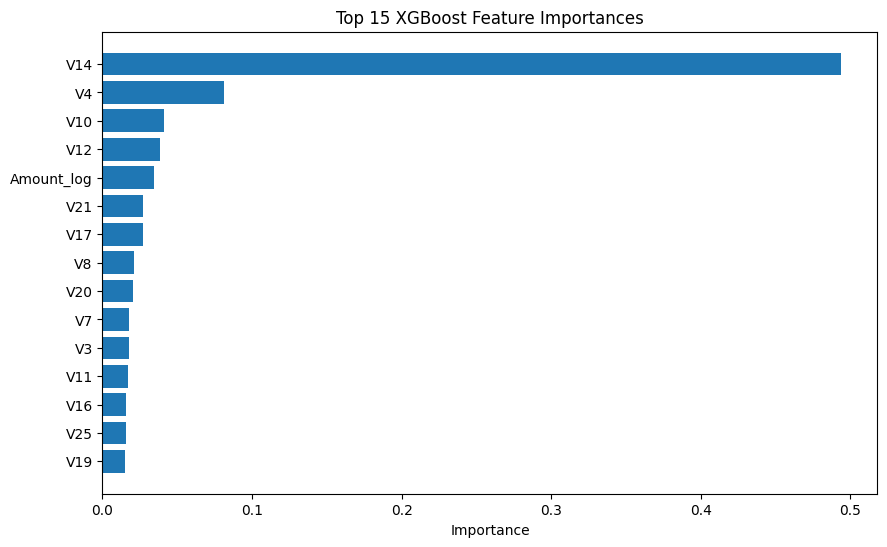

In [38]:

top_features = importance_df.head(15)

plt.figure(figsize=(10, 6))
plt.barh(top_features["feature"], top_features["importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Top 15 XGBoost Feature Importances")
plt.show()

## Suggested final conclusion

The Gaussian anomaly detection model was useful as an unsupervised baseline and helped identify unusual transactions. However, its fraud recall and precision were limited due to the complex distribution of the dataset. XGBoost performed better because it used labelled fraud examples during training and could learn more complex relationships between features. Hyperparameter tuning and threshold adjustment further helped balance precision and recall.